In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Case 1: Starting without intercept

creating the vectors

In [2]:
# create 2 orthorgonal vectors
x1 = np.array([4,4,1])
x2 = np.array([-4,3,4])

# validate their orthorgonality
dot_product = x1.dot(x2)
if x1.dot(x2) == 0:
    print(f'x1 and x2 are orthorgonal; dot product:{dot_product}')
else:
    print(f'x1 and x2 are not orthorgonal; dot product:{dot_product}')

# create a y vector
y = np.array([0,5,5])



x1 and x2 are orthorgonal; dot product:0


plotting vectors x1,x2 and y with the column space of X (space spanned by x1 and x2)

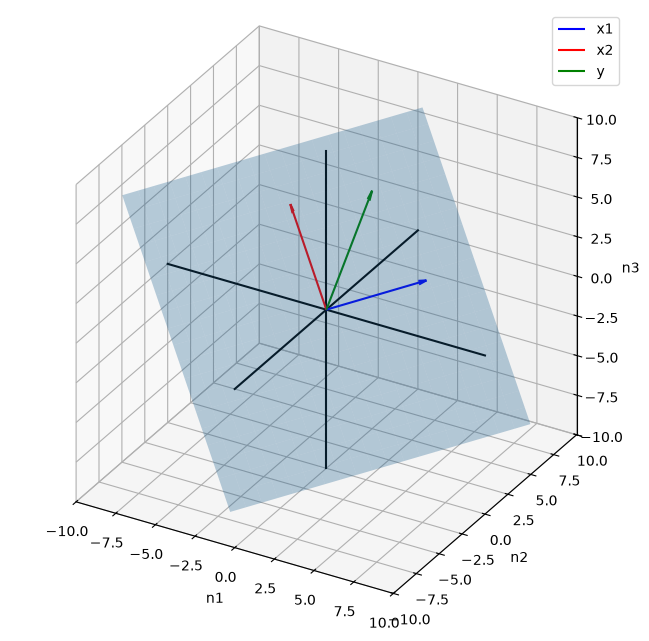

In [3]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# Limits
lim = 10

ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_zlim(-lim, lim)

# Axes through (0, 0, 0)
ax.plot([-lim, lim], [0, 0], [0, 0], color="black")
ax.plot([0, 0], [-lim, lim], [0, 0], color="black")
ax.plot([0, 0], [0, 0], [-lim, lim], color="black")

# Plot x1, x2 and y
ax.quiver(
    0, 0, 0,
    *x1,
    color="blue",
    label="x1",
    arrow_length_ratio=0.08
)

ax.quiver(
    0, 0, 0,
    *x2,
    color="red",
    label="x2",
    arrow_length_ratio=0.08
)

ax.quiver(
    0, 0, 0,
    *y,
    color="green",
    label="y",
    arrow_length_ratio=0.08
)


# Assume dataset has 3 observations ; ambient space R^3
ax.set_xlabel("n1")
ax.set_ylabel("n2")
ax.set_zlabel("n3")

# -------- plane spanned by x1 and x2 --------
a_vals = np.linspace(-1.5, 1.5, 20)
b_vals = np.linspace(-1.5, 1.5, 20)
A, B = np.meshgrid(a_vals, b_vals)

X_plane = A * x1[0] + B * x2[0]
Y_plane = A * x1[1] + B * x2[1]
Z_plane = A * x1[2] + B * x2[2]

ax.plot_surface(X_plane, Y_plane, Z_plane, alpha=0.3)

# Equal visual scaling
ax.set_box_aspect((1, 1, 1))

# Orthographic projection reduces perspective distortion
ax.set_proj_type("ortho")

ax.legend()

plt.show()

Direct Solution vs Gram-Schmidt via Successive Orthogonalisation ; prove that if x1 and x2 are orthorgonal they yield the same resulting vector y_hat

In [4]:
# Direct Decoupling Solution
# y = b_x1 * x1 + b_x2 * x2 + eps

# projection coefficient of y onto x1
b_x1_hat = x1.dot(y)/x1.dot(x1)

# projection coefficint of y onto x2
b_x2_hat = x2.dot(y)/x2.dot(x2)

print(f'b_x1_hat: {b_x1_hat}')
print(f'b_x2_hat: {b_x2_hat}')

# projection vector of y onto x1
proj_y_x1 = b_x1_hat * x1
# projection vector of y onto x2
proj_y_x2 = b_x2_hat * x2

print(f'proj_y_x1: {proj_y_x1}')
print(f'proj_y_x2: {proj_y_x2}')

# y_hat = b_x1_hat * x1 + b_x2_hat * x2 = y_x1_hat + y_x2_hat
# projection vector y_hat can be found by the direct addition of proj vector of y onto x1 and proj vector of y onto x2 since x1 and x2 are orthogonal
y_hat = proj_y_x1 + proj_y_x2
print(f'y_hat: {y_hat}')



b_x1_hat: 0.7575757575757576
b_x2_hat: 0.8536585365853658
proj_y_x1: [3.03030303 3.03030303 0.75757576]
proj_y_x2: [-3.41463415  2.56097561  3.41463415]
y_hat: [-0.38433112  5.59127864  4.1722099 ]


In [5]:
# Solving with Gram-Schimdt via successive orthogonalisation
# Since Gram-Schimdt seeks to find an orthogonal basis, and if we let the first vector of the algorithm be x1, let z1 =x1

# 1) First Direction
z1 = x1

# 2) orthogonalise x2 with respect to z1
proj_x2_z1 = z1.dot(x2)/z1.dot(z1) * z1
z2 = x2 - proj_x2_z1

# but since z1.dot(x2) = 0 since z1 = x1 and, x1 and x2 are orthogonal, z2 = x2
print(f'proj_x2_z1:{proj_x2_z1}')
print(f'is z2 = x2?:{z2==x2}')


# 3) project y successively onto these orthogonal projections
proj_y_z1 = z1.dot(y)/z1.dot(z1) * z1
proj_y_z2 = z2.dot(y)/z2.dot(z2) * z2

print(f'proj_y_z1: {proj_y_z1}')
print(f'proj_y_z2: {proj_y_z2}')

# y_hat solution via Gram-Schmidt algo
y_hat_GD = proj_y_z1 + proj_y_z2
print(f'y_hat_GD:{y_hat_GD}')



print(f'y_hat equal to y_hat_GD?: {y_hat == y_hat_GD}')

proj_x2_z1:[0. 0. 0.]
is z2 = x2?:[ True  True  True]
proj_y_z1: [3.03030303 3.03030303 0.75757576]
proj_y_z2: [-3.41463415  2.56097561  3.41463415]
y_hat_GD:[-0.38433112  5.59127864  4.1722099 ]
y_hat equal to y_hat_GD?: [ True  True  True]


y_hat is the same because x1 and x2 are orthogonal so there is nothing to residualise. Orthogonalising x2 wrt to z1 if finding the component of x2 not already captured by z1. In the case where x2 and x1 (and hence to z1, since z1 = x1) are orthogonal, there is no component of x2 lies in the span of z1, so the component of x2 not already represented by z1 is still x2 (which is now noted as z2 in our algo). So z1 = x1 and z2 = x2.

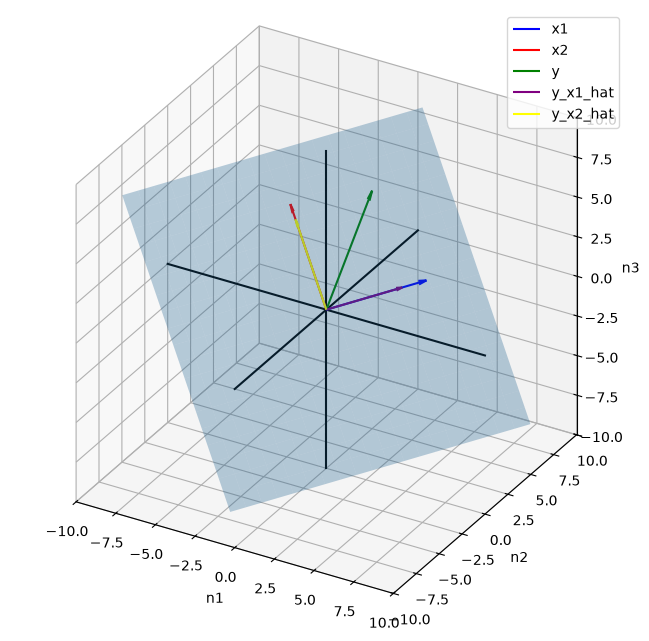

In [6]:

# Plot projections of y onto x1 and x2
ax.quiver(
    0, 0, 0,
    *proj_y_x1,
    color="purple",
    label="y_x1_hat",
    arrow_length_ratio=0.08
)

ax.quiver(
    0, 0, 0,
    *proj_y_x2,
    color="yellow",
    label="y_x2_hat",
    arrow_length_ratio=0.08
)

ax.legend()
display(fig)


Validating y_hat vector with the closed-form solution

b_hat_closed_form: [0.75757576 0.85365854]
y_hat_closed_form: [-0.38433112  5.59127864  4.1722099 ]
validation diff vector: [ 4.4408921e-16  0.0000000e+00 -8.8817842e-16]
validation diff norm: 9.930136612989092e-16


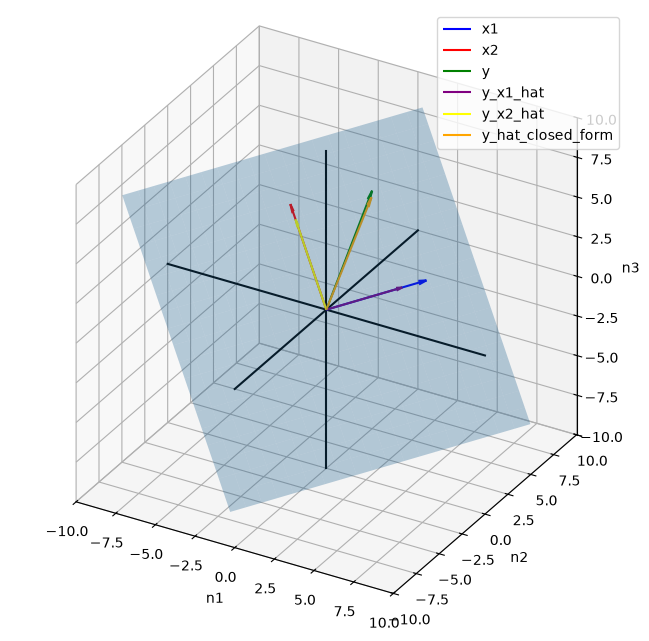

In [7]:

#validating via normal eqns
X = np.stack((x1,x2),axis=1)
b_hat_closed_form =  np.linalg.inv(X.T @ X) @ X.T @ y
y_hat_closed_form =  X @ b_hat_closed_form

print(f'b_hat_closed_form: {b_hat_closed_form}')
print(f'y_hat_closed_form: {y_hat_closed_form}')

diff = y_hat - y_hat_closed_form

print(f"validation diff vector: {diff}")
print(f"validation diff norm: {np.linalg.norm(diff)}") #l2 norm


# y hat closed form = y_hat = y_x1_hat + y_x2_hat


ax.quiver(
    0, 0, 0,
    *y_hat_closed_form,
    color="orange",
    label="y_hat_closed_form",
    arrow_length_ratio=0.08
)

ax.legend()
display(fig)

# What if our column vectors were not perfectly orthogonal?

here x3 and x4 are not orthogonal ; verified by their dot product != 0

In [8]:
# create 2 non-orthorgonal vectors
x3 = np.array([4,4,1])
x4 = np.array([-4,3,3])

# validate their non-orthorgonality
dot_product = x3.dot(x4)
if x1.dot(x2) == 0:
    print(f'x3 and x4 are orthorgonal; dot product:{dot_product}')
else:
    print(f'x3 and x4 are not orthorgonal; dot product:{dot_product}')

    # create a y vector
y = np.array([0,5,5])

x3 and x4 are orthorgonal; dot product:-1


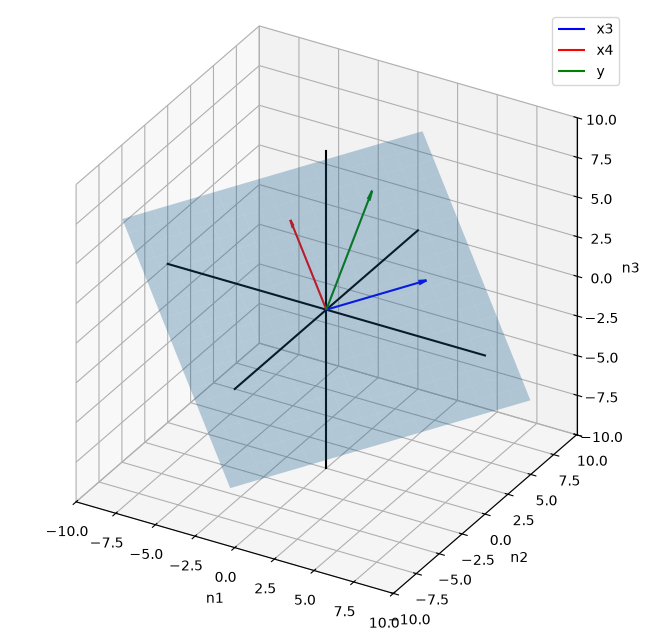

In [9]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# Limits
lim = 10

ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_zlim(-lim, lim)

# Axes through (0, 0, 0)
ax.plot([-lim, lim], [0, 0], [0, 0], color="black")
ax.plot([0, 0], [-lim, lim], [0, 0], color="black")
ax.plot([0, 0], [0, 0], [-lim, lim], color="black")

# Plot x3, x4 and y
ax.quiver(
    0, 0, 0,
    *x3,
    color="blue",
    label="x3",
    arrow_length_ratio=0.08
)

ax.quiver(
    0, 0, 0,
    *x4,
    color="red",
    label="x4",
    arrow_length_ratio=0.08
)

ax.quiver(
    0, 0, 0,
    *y,
    color="green",
    label="y",
    arrow_length_ratio=0.08
)


# Assume dataset has 3 observations ; ambient space R^3
ax.set_xlabel("n1")
ax.set_ylabel("n2")
ax.set_zlabel("n3")

# -------- plane spanned by x3 and x4 --------
a_vals = np.linspace(-1.5, 1.5, 20)
b_vals = np.linspace(-1.5, 1.5, 20)
A, B = np.meshgrid(a_vals, b_vals)

X_plane = A * x3[0] + B * x4[0]
Y_plane = A * x3[1] + B * x4[1]
Z_plane = A * x3[2] + B * x4[2]

ax.plot_surface(X_plane, Y_plane, Z_plane, alpha=0.3)

# Equal visual scaling
ax.set_box_aspect((1, 1, 1))

# Orthographic projection reduces perspective distortion
ax.set_proj_type("ortho")

ax.legend()

plt.show()

Show that direct orthogonal decomposition does not work anymore when our columns are not orthogonal

In [10]:
# Direct solution for orthogonal predictors
# y_hat = b_x3_hat * x3 + b_x4_hat * x4

# projection coefficient of y onto x3
b_x3_hat = x3.dot(y)/x3.dot(x3)

# projection coefficint of y onto x4
b_x4_hat = x4.dot(y)/x4.dot(x4)

print(f'b_x3_hat: {b_x3_hat}')
print(f'b_x4_hat: {b_x4_hat}')

# projection vector of y onto x3
proj_y_x3 = b_x3_hat * x3
# projection vector of y onto x4
proj_y_x4 = b_x4_hat * x4

print(f'proj_y_x3: {proj_y_x3}')
print(f'proj_y_x4: {proj_y_x4}')

# y_hat = b_x3_hat * x3 + b_x4_hat * x4 = y_x3_hat + y_x4_hat

y_hat = proj_y_x3 + proj_y_x4
print(f'y_hat: {y_hat}')



b_x3_hat: 0.7575757575757576
b_x4_hat: 0.8823529411764706
proj_y_x3: [3.03030303 3.03030303 0.75757576]
proj_y_x4: [-3.52941176  2.64705882  2.64705882]
y_hat: [-0.49910873  5.67736185  3.40463458]


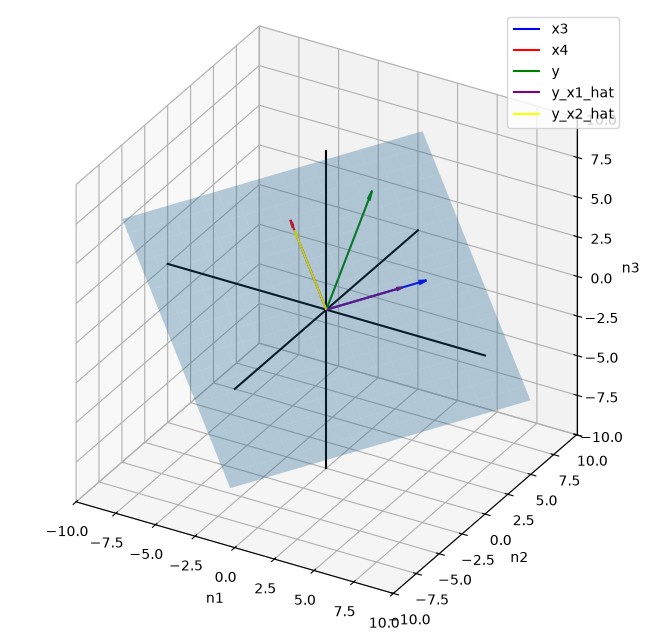

In [11]:
# Plot projections of y onto x3 and x4
ax.quiver(
    0, 0, 0,
    *proj_y_x3,
    color="purple",
    label="y_x1_hat",
    arrow_length_ratio=0.08
)

ax.quiver(
    0, 0, 0,
    *proj_y_x4,
    color="yellow",
    label="y_x2_hat",
    arrow_length_ratio=0.08
)

ax.legend()
display(fig)


In [12]:
# Solving with Gram-Schimdt via successive orthogonalisation
# Since Gram-Schimdt seeks to find an orthogonal basis, and if we let the first vector of the algorithm be x3, let z3 =x3

# 1) First Direction
z3 = x3

# 2) orthogonalise x4 with respect to z3
proj_x4_z3 = z3.dot(x4)/z3.dot(z3) * z3
z4 = x4 - proj_x4_z3

# here since z3 and x4 are not orthogonal, z3.dot(x4) != 0 and proj_x4_z3 != 0, so z4 != x4
print(f'proj_x4_z3:{proj_x4_z3}')
print(f'is z4 = x4?:{z4==x4}')


# 3) project y successively onto these orthogonal projections
proj_y_z3 = z3.dot(y)/z3.dot(z3) * z3
proj_y_z4 = z4.dot(y)/z4.dot(z4) * z4

print(f'proj_y_z3: {proj_y_z3}')
print(f'proj_y_z4: {proj_y_z4}')

# y_hat solution via Gram-Schmidt algo
y_hat_GD = proj_y_z3 + proj_y_z4
print(f'y_hat_GD:{y_hat_GD}')



print(f'y_hat equal to y_hat_GD?: {y_hat == y_hat_GD}')

proj_x4_z3:[-0.12121212 -0.12121212 -0.03030303]
is z4 = x4?:[False False False]
proj_y_z3: [3.03030303 3.03030303 0.75757576]
proj_y_z4: [-3.51201579  2.8260752   2.74376233]
y_hat_GD:[-0.48171276  5.85637823  3.50133809]
y_hat equal to y_hat_GD?: [False False False]


if columns of X are not orthogonal, we cannot get the solution via summation of the projections of y onto the columns of X.

b_hat_closed_form: [0.78501338 0.90544157]
y_hat_closed_form: [-0.48171276  5.85637823  3.50133809]


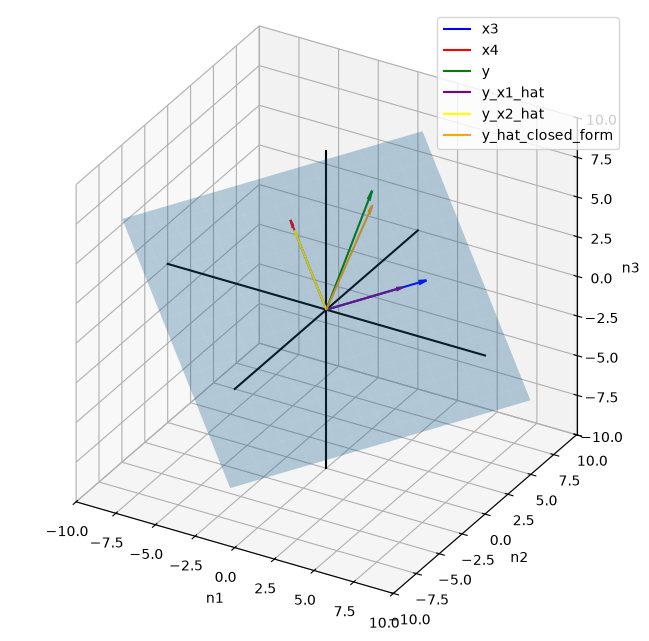

In [13]:
# validating solution of Gram-Schimdt with solution via normal eqns
X = np.stack((x3,x4),axis=1)
b_hat_closed_form =  np.linalg.inv(X.T @ X) @ X.T @ y
y_hat_closed_form =  X @ b_hat_closed_form

print(f'b_hat_closed_form: {b_hat_closed_form}')
print(f'y_hat_closed_form: {y_hat_closed_form}')



ax.quiver(
    0, 0, 0,
    *y_hat_closed_form,
    color="orange",
    label="y_hat_closed_form",
    arrow_length_ratio=0.08
)

ax.legend()
display(fig)

In [14]:
# x3 and x4 are not orthogonal
print(f'direct solution for orthogonal predictors ; x3 and x4 are NOT orthogonal :{y_hat}') # y_hat
print(f'Gram-Schimdt (Successive Orthogonalisation) solution ; x3 and x4 are NOT orthogonal :{y_hat_GD}') # y_hat from Gram schimdt algo
print(f'Closed-Form Normal Eqn solution ; x3 and x4 are NOT orthogonal :{y_hat_closed_form}') # y_hat form closed form norm eqn

# we can see that if the cols of X are not orthogonal, y_hat is not just a direct decomposition of proj_y_x3 (vector of y projected on x3) and proj_y_x4 (vector of y projected on x4).



# Numerical validation of y_hat annd y_hat_GD
prediction_diff = y_hat - y_hat_GD 

print(f"prediction diff vector: {prediction_diff}")
print(f"prediction diff norm: {np.linalg.norm(prediction_diff)}") #l2 norm


direct solution for orthogonal predictors ; x3 and x4 are NOT orthogonal :[-0.49910873  5.67736185  3.40463458]
Gram-Schimdt (Successive Orthogonalisation) solution ; x3 and x4 are NOT orthogonal :[-0.48171276  5.85637823  3.50133809]
Closed-Form Normal Eqn solution ; x3 and x4 are NOT orthogonal :[-0.48171276  5.85637823  3.50133809]
prediction diff vector: [-0.01739598 -0.17901638 -0.09670351]
prediction diff norm: 0.20420835717575098


In [ ]:
# algo for Gram-Schimdt
def gram_schimdt():
    pass